In [1]:
from raman_data import raman_data

# Display the available dataset catalogue
catalogue = raman_data()
print(catalogue)

2026-09-25 22:21:08,350 INFO raman_data:raman_data:61: Listing available datasets


['diabetes_skin_ages', 'diabetes_skin_ear_lobe', 'diabetes_skin_inner_arm', 'diabetes_skin_thumbnail', 'diabetes_skin_vein', 'amino_acids_glycine', 'amino_acids_leucine', 'amino_acids_phenylalanine', 'amino_acids_tryptophan', 'cancer_cell_cooh', 'cancer_cell_nh2', 'cancer_cell_(cooh)2', 'bioprocess_substrates', 'ecoli_fermentation', 'fuel_benchtop', 'fuel_handheld', 'yeast_fermentation', 'ralstonia_fermentations', 'bioprocess_analytes_anton_532', 'bioprocess_analytes_anton_785', 'bioprocess_analytes_kaiser', 'bioprocess_analytes_metrohm', 'bioprocess_analytes_mettler_toledo', 'bioprocess_analytes_tec5', 'bioprocess_analytes_timegate', 'bioprocess_analytes_tornado', 'ecoli_metabolites_dig4bio', 'ecoli_metabolites', 'ht_raman_bio_catalysis_axp', 'streptococcus_thermophilus_fermentation_timegate', 'streptococcus_thermophilus_fermentation_kaiser', 'kaiser_ecoli_fermentation_supernatant', 'kaiser_ecoli_fermentation', 'tg_ecoli_fermentation_supernatant', 'tg_ecoli_fermentation', 'sugar_mixtu

In [3]:
# raman_data() returns a list of dataset keys, so filter the strings directly.
rruff_datasets = [key for key in catalogue if "rruff" in key.lower()]
print(rruff_datasets)

['rruff_mineral_raw', 'rruff_mineral_preprocess']


In [4]:
# Replace this with the exact key shown in your catalogue
dataset_key = "rruff_mineral_raw"  # or "rruff_mineral_preprocess"

ds = raman_data(dataset_key)

X = ds.spectra
y = ds.targets
wavenumbers = ds.raman_shifts

print("Spectra shape:", X.shape)
print("Labels shape:", y.shape)
print("Wavenumber axis shape:", wavenumbers.shape)

2026-09-25 22:29:54,135 INFO raman_data:raman_data:67: Loading dataset: rruff_mineral_raw (cache_dir=None)
Downloading...
From (original): https://drive.google.com/uc?id=1X5OAdugcHVOF6k9WaWwCAu_IFh_7OwzR
From (redirected): https://drive.google.com/uc?id=1X5OAdugcHVOF6k9WaWwCAu_IFh_7OwzR&confirm=t&uuid=43d85117-e09d-4979-9ce2-fcb5a7256c42
To: C:\Users\jothe\.cache\raman-data\gdrive\dtu_raman_shared\public_dataset.zip
100%|██████████| 603M/603M [00:36<00:00, 16.6MB/s] 
100%|██████████| 26.0/26.0 [00:07<00:00, 3.69files/s]


Spectra shape: (5244, 1142)
Labels shape: (5244,)
Wavenumber axis shape: (1142,)


In [5]:
import numpy as np
import pandas as pd

X = np.asarray(ds.spectra)
y = np.asarray(ds.targets)
wavenumbers = np.asarray(ds.raman_shifts)

print(f"Number of spectra: {X.shape[0]}")
print(f"Features per spectrum: {X.shape[1]}")
print(f"Number of labels: {y.shape[0]}")
print(f"Number of wavenumbers: {wavenumbers.shape[0]}")

print("\nData types")
print("X:", X.dtype)
print("y:", y.dtype)
print("wavenumbers:", wavenumbers.dtype)

assert X.ndim == 2, "Expected X to be a 2D array"
assert y.ndim == 1, "Expected y to be a 1D array"
assert X.shape[0] == y.shape[0], "Spectra and labels don't match"
assert X.shape[1] == wavenumbers.shape[0], "Wavenumber axis doesn't match X"

Number of spectra: 5244
Features per spectrum: 1142
Number of labels: 5244
Number of wavenumbers: 1142

Data types
X: float64
y: int64
wavenumbers: float64


In [6]:
print("Missing values in spectra:", np.isnan(X).sum())
print("Infinite values in spectra:", np.isinf(X).sum())
print("Missing labels:", pd.isna(y).sum())

print("\nIntensity summary")
print("Minimum:", np.nanmin(X))
print("Maximum:", np.nanmax(X))
print("Mean:", np.nanmean(X))
print("Standard deviation:", np.nanstd(X))

print("\nWavenumber range")
print("Minimum:", wavenumbers.min(), "cm⁻¹")
print("Maximum:", wavenumbers.max(), "cm⁻¹")

Missing values in spectra: 0
Infinite values in spectra: 0
Missing labels: 0

Intensity summary
Minimum: -241.19544283547427
Maximum: 2310312.987762073
Mean: 740.6661626135923
Standard deviation: 7660.656956459002

Wavenumber range
Minimum: 303.2099 cm⁻¹
Maximum: 853.1719000000317 cm⁻¹


In [7]:
label_counts = (
    pd.Series(y, name="mineral")
    .value_counts()
    .rename_axis("mineral")
    .reset_index(name="n_spectra")
)

print("Number of unique classes:", label_counts.shape[0])
display(label_counts.head(20))

print("\nClass-size summary")
display(label_counts["n_spectra"].describe())

Number of unique classes: 1685


,mineral,n_spectra
0,637,40
1,407,30
2,458,29
3,55,27
4,164,26
5,245,26
6,550,25
7,29,24
8,415,23
9,446,23



Class-size summary


count    1685.000000
mean        3.112166
std         3.279154
min         1.000000
25%         2.000000
50%         2.000000
75%         4.000000
max        40.000000
Name: n_spectra, dtype: float64

2026-09-25 22:32:39,263 INFO matplotlib.font_manager:_load_fontmanager:1848: generated new fontManager
2026-09-25 22:32:40,117 INFO matplotlib.category:update:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-25 22:32:40,137 INFO matplotlib.category:update:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


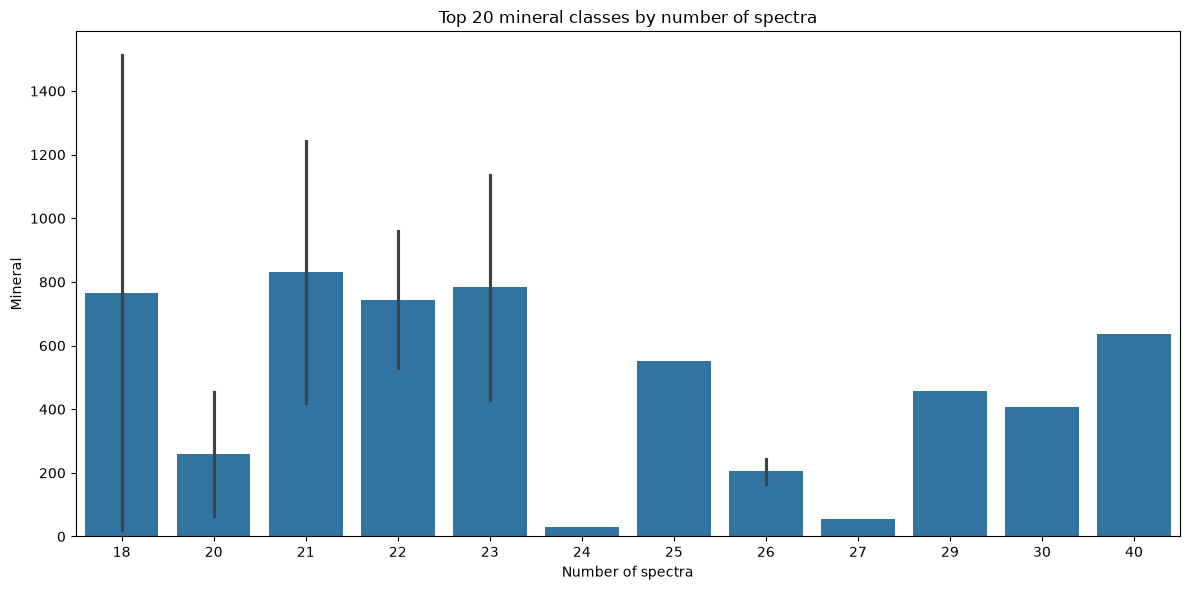

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

top_n = 20

plt.figure(figsize=(12, 6))
sns.barplot(
    data=label_counts.head(top_n),
    x="n_spectra",
    y="mineral"
)
plt.title(f"Top {top_n} mineral classes by number of spectra")
plt.xlabel("Number of spectra")
plt.ylabel("Mineral")
plt.tight_layout()
plt.show()